# Sesión 03 — Biblioteca universal de rótulas

Este notebook lee siempre el caso indicado en `PUSHOVER_PORTABLE/casos/MI_EDIFICIO/entrada_maestra.json`. No contiene un ejemplo separado: cambia los JSON de entrada y vuelve a ejecutar el cuaderno.


In [40]:
from pathlib import Path
import sys, json

def buscar_raiz(inicio=None):
    inicio = Path.cwd() if inicio is None else Path(inicio)
    for carpeta in (inicio, *inicio.parents):
        if (carpeta / 'temario.md').is_file() and (carpeta / 'PUSHOVER_PORTABLE').is_dir():
            return carpeta
    raise FileNotFoundError('No se encontró la raíz del repositorio.')

RAIZ = buscar_raiz()
PORTABLE = RAIZ / 'PUSHOVER_PORTABLE'
sys.path.insert(0, str(PORTABLE))
RUTA_MAESTRA = PORTABLE / 'casos' / 'edificio_6pisos' / 'entrada_maestra.json'
entrada, RUTA_GEOMETRIA, _ = __import__('ejecutar_pushover').cargar_entrada_maestra(RUTA_MAESTRA)
CASO_ID = entrada['caso_id']
print('Caso:', CASO_ID, '| geometría:', RUTA_GEOMETRIA)


Caso: edificio_6pisos | geometría: D:\DOCENCIA\PRINBEL\PUSHOVER PORTICOS\PUSHOVER_PORTABLE\casos\edificio_6pisos\geometria_secciones.json


In [41]:
from sesion_03.biblioteca_rotulas import generar_biblioteca_desde_entrada, guardar_contrato_sesion03, leer_contrato_sesion03

biblioteca, metadata = generar_biblioteca_desde_entrada(RUTA_GEOMETRIA)
salida = RAIZ / 'resultados_curso_portable' / CASO_ID / 'sesion_03'
ruta_contrato = salida / 'contrato_sesion03.json'
guardar_contrato_sesion03(biblioteca, ruta_contrato, schema_version='3.5', metadata_adicional={'caso_id': CASO_ID, 'entrada_maestra': str(RUTA_MAESTRA.relative_to(RAIZ)), 'secciones': metadata})
contrato = leer_contrato_sesion03(ruta_contrato)
assert set(contrato['biblioteca_rotulas']) == set(entrada['secciones'])
for sid, familia in contrato['biblioteca_rotulas'].items():
    assert familia['positivo'] and familia['negativo']
    for sentido in ('positivo', 'negativo'):
        for estado in familia[sentido]:
            ley = estado['ley']
            assert estado['EI_sec_kgf_cm2'] > 0 and 0 < ley['My_kgf_cm'] <= ley['Mu_kgf_cm']
print('Secciones:', ', '.join(contrato['biblioteca_rotulas']))
print('Contrato guardado:', ruta_contrato)


Secciones: C1, C2, C3, V1, V2, V3
Contrato guardado: d:\DOCENCIA\PRINBEL\PUSHOVER PORTICOS\resultados_curso_portable\edificio_6pisos\sesion_03\contrato_sesion03.json


## Verificación

Revisa que la malla axial cubra las demandas gravitacionales previstas, que `EI_sec` sea positivo y que las leyes tengan ramas positiva y negativa. La salida de esta sesión alimenta directamente la sesión 04 y la sesión 05.


## Diagnóstico posterior a la curva de capacidad

Ejecuta las celdas siguientes **después de completar la sesión 06**. El diagnóstico es universal: lee los resultados del mismo `CASO_ID`, explica la razón de parada, calcula la utilización de las rótulas, localiza la concentración de derivas y relaciona las rótulas críticas con cambios de sección. Si todavía no existe la curva, las celdas informan qué archivo falta sin interrumpir la sesión 03.


In [42]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def buscar_raiz_diagnostico(inicio=None):
    carpeta = Path.cwd() if inicio is None else Path(inicio)
    for candidata in (carpeta, *carpeta.parents):
        if (candidata / 'temario.md').is_file() and (candidata / 'PUSHOVER_PORTABLE').is_dir():
            return candidata
    raise FileNotFoundError('No se encontró la raíz del repositorio. Ubica el entorno dentro de PUSHOVER_PORTICOS_COLAB.')

RAIZ = buscar_raiz_diagnostico()
RUTA_MAESTRA_DIAGNOSTICO = RAIZ / 'PUSHOVER_PORTABLE' / 'casos' / 'edificio_6pisos' / 'entrada_maestra.json'
if not RUTA_MAESTRA_DIAGNOSTICO.is_file():
    raise FileNotFoundError(f'No se encontró la entrada maestra: {RUTA_MAESTRA_DIAGNOSTICO}')
CASO_ID = str(json.loads(RUTA_MAESTRA_DIAGNOSTICO.read_text(encoding='utf-8'))['caso_id'])
BASE_RESULTADOS = RAIZ / 'resultados_curso_portable' / CASO_ID
RUTA_RESULTADOS_S6 = BASE_RESULTADOS / 'sesion_06' / 'resultados_pushover.json'
RUTA_CONTRATO_CAL = BASE_RESULTADOS / 'sesion_05' / 'contrato_sesion05_calibrado.json'
POSPROCESO_DISPONIBLE = RUTA_RESULTADOS_S6.is_file() and RUTA_CONTRATO_CAL.is_file()

if not POSPROCESO_DISPONIBLE:
    print('Diagnóstico pendiente: ejecuta primero las sesiones 04, 05 y 06.')
    print('Resultado esperado:', RUTA_RESULTADOS_S6)
    print('Contrato esperado :', RUTA_CONTRATO_CAL)
else:
    resultados_s6 = json.loads(RUTA_RESULTADOS_S6.read_text(encoding='utf-8'))
    contrato_cal = json.loads(RUTA_CONTRATO_CAL.read_text(encoding='utf-8'))
    historia = resultados_s6['historia']
    eventos = resultados_s6.get('eventos', [])
    print('Curva cargada:', len(historia), 'puntos')
    print('Convergió:', resultados_s6.get('convergio'))
    print('Razón de parada:', resultados_s6.get('razon_parada'))


Curva cargada: 141 puntos
Convergió: True
Razón de parada: desplazamiento_maximo


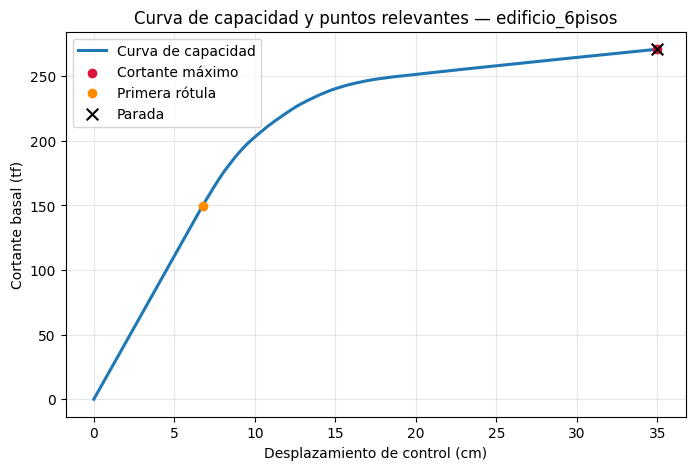

,puntos,u_final_cm,V_final_tf,u_Vmax_cm,Vmax_tf,deriva_max_final_pct,rotulas_formadas,razon_parada
0,141,35.0,270.8838,35.0,270.8838,2.4992,98,desplazamiento_maximo


In [43]:
if POSPROCESO_DISPONIBLE:
    tabla_historia = pd.DataFrame(historia)
    u = tabla_historia['desplazamiento_control_cm'].to_numpy(float)
    V = tabla_historia['cortante_basal_kgf'].to_numpy(float) / 1000.0
    i_max = int(np.argmax(V))
    formaciones = [e for e in eventos if e.get('tipo') == 'formacion_rotula']

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(u, V, lw=2.2, label='Curva de capacidad')
    ax.scatter(u[i_max], V[i_max], color='crimson', zorder=4, label='Cortante máximo')
    if formaciones:
        primera = formaciones[0]
        ax.scatter(primera['desplazamiento_control_cm'], primera['cortante_basal_kgf']/1000, color='darkorange', zorder=4, label='Primera rótula')
    ax.scatter(u[-1], V[-1], color='black', marker='x', s=70, zorder=5, label='Parada')
    ax.set(xlabel='Desplazamiento de control (cm)', ylabel='Cortante basal (tf)', title=f'Curva de capacidad y puntos relevantes — {CASO_ID}')
    ax.legend(); ax.grid(True, alpha=0.3); plt.show()

    resumen_curva = pd.DataFrame([{
        'puntos': len(historia),
        'u_final_cm': u[-1],
        'V_final_tf': V[-1],
        'u_Vmax_cm': u[i_max],
        'Vmax_tf': V[i_max],
        'deriva_max_final_pct': 100*float(historia[-1].get('deriva_maxima', np.nan)),
        'rotulas_formadas': len(formaciones),
        'razon_parada': resultados_s6.get('razon_parada', ''),
    }])
    display(resumen_curva.round(4))


In [44]:
if POSPROCESO_DISPONIBLE:
    elementos = {int(e['id']): e for e in contrato_cal['elementos']}
    rotulas = {str(r['id']): r for r in contrato_cal['rotulas']}
    estados = resultados_s6.get('estado_final_rotulas', {})
    nodos = {int(k): np.asarray(v, dtype=float) for k, v in contrato_cal['nodos'].items()}
    elevaciones = sorted({float(xy[1]) for xy in nodos.values() if float(xy[1]) > 0})

    filas_rotulas = []
    for rid, estado in estados.items():
        if not estado.get('activa') or rid not in rotulas:
            continue
        rotula = rotulas[rid]
        sentido = estado.get('sentido_momento', 'positivo')
        ley = rotula.get('ley_por_sentido', {}).get(sentido, rotula.get('ley', {}))
        capacidad = float(ley.get('theta_p_u_rad', np.nan))
        demanda = abs(float(estado.get('theta_p_rad', 0.0)))
        elemento = elementos[int(rotula['elemento'])]
        y_superior = max(nodos[int(elemento['i'])][1], nodos[int(elemento['j'])][1])
        nivel = int(np.argmin(np.abs(np.asarray(elevaciones)-y_superior))) + 1
        filas_rotulas.append({
            'rotula': rid, 'elemento': int(elemento['id']), 'tipo': elemento['tipo'],
            'portico': elemento.get('id_portico'), 'nivel': nivel, 'seccion': elemento.get('seccion_id'),
            'theta_demanda_rad': demanda, 'theta_capacidad_rad': capacidad,
            'utilizacion': demanda/capacidad if capacidad > 0 else np.nan,
            'desempeno': estado.get('desempeno'),
        })

    columnas_rotulas = ['rotula','elemento','tipo','portico','nivel','seccion','theta_demanda_rad','theta_capacidad_rad','utilizacion','desempeno']
    tabla_rotulas = pd.DataFrame(filas_rotulas, columns=columnas_rotulas).sort_values('utilizacion', ascending=False)
    print('Rótulas activas ordenadas por demanda/capacidad:')
    display(tabla_rotulas.head(20).round(5))
    criticas = tabla_rotulas[tabla_rotulas['utilizacion'] >= 0.90].copy()
    if criticas.empty:
        print('Ninguna rótula activa supera 90 % de su capacidad calculada.')
    else:
        print('Rótulas con utilización ≥ 90 %:', ', '.join(criticas['rotula']))


Rótulas activas ordenadas por demanda/capacidad:


,rotula,elemento,tipo,portico,nivel,seccion,theta_demanda_rad,theta_capacidad_rad,utilizacion,desempeno
50,E62-i,62,columna,P3,1,C1,0.01235,0.02079,0.59422,LS
27,E32-i,32,columna,P2,1,C1,0.01234,0.02079,0.59385,LS
59,E70-j,70,viga,P3,2,V1,0.02218,0.04069,0.54517,CP
36,E40-j,40,viga,P2,2,V1,0.02219,0.04071,0.54508,CP
34,E39-j,39,viga,P2,2,V1,0.02119,0.04069,0.52080,CP
57,E69-j,69,viga,P3,2,V1,0.02119,0.04071,0.52043,CP
83,E100-j,100,viga,P4,2,V1,0.02075,0.04073,0.50940,CP
11,E10-j,10,viga,P1,2,V1,0.02076,0.04080,0.50892,CP
73,E92-i,92,columna,P4,1,C1,0.01433,0.02881,0.49743,LS
1,E2-i,2,columna,P1,1,C1,0.01432,0.02881,0.49705,LS


Ninguna rótula activa supera 90 % de su capacidad calculada.


,nivel,deriva_media_pct,deriva_max_pct
0,1,1.908,1.909
1,2,2.275,2.275
2,3,2.499,2.499
3,4,2.345,2.346
4,5,1.805,1.807
5,6,0.835,0.838


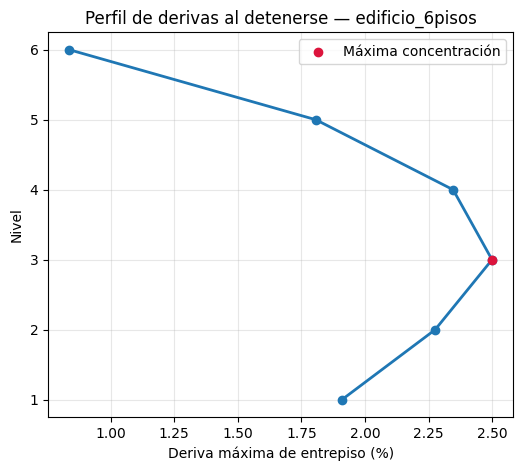

Nivel crítico: 3; deriva=2.499 %; índice respecto a la mediana restante=1.31.


In [45]:
if POSPROCESO_DISPONIBLE:
    derivas = historia[-1].get('derivas_por_portico', {})
    if derivas:
        matriz_derivas = np.asarray(list(derivas.values()), dtype=float)
        maxima_nivel = np.max(matriz_derivas, axis=0)
        media_nivel = np.mean(matriz_derivas, axis=0)
        nivel_critico = int(np.argmax(maxima_nivel)) + 1
        referencia = np.median(np.delete(maxima_nivel, nivel_critico-1)) if len(maxima_nivel) > 1 else maxima_nivel[0]
        indice_concentracion = maxima_nivel[nivel_critico-1]/referencia if referencia > 0 else np.nan
        tabla_derivas = pd.DataFrame({'nivel': np.arange(1, len(maxima_nivel)+1), 'deriva_media_pct':100*media_nivel, 'deriva_max_pct':100*maxima_nivel})
        display(tabla_derivas.round(3))
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(100*maxima_nivel, np.arange(1,len(maxima_nivel)+1), 'o-', lw=2)
        ax.scatter(100*maxima_nivel[nivel_critico-1], nivel_critico, color='crimson', zorder=4, label='Máxima concentración')
        ax.set(xlabel='Deriva máxima de entrepiso (%)', ylabel='Nivel', title=f'Perfil de derivas al detenerse — {CASO_ID}')
        ax.set_yticks(np.arange(1,len(maxima_nivel)+1)); ax.grid(True, alpha=0.3); ax.legend(); plt.show()
        print(f'Nivel crítico: {nivel_critico}; deriva={100*maxima_nivel[nivel_critico-1]:.3f} %; índice respecto a la mediana restante={indice_concentracion:.2f}.')

    secciones_diagnostico = contrato_cal.get('secciones', {})
    if not secciones_diagnostico:
        manifiesto_diag = json.loads(RUTA_MAESTRA_DIAGNOSTICO.read_text(encoding='utf-8'))
        referencia_geo = Path(manifiesto_diag['archivos']['geometria_y_secciones'])
        ruta_geo_diag = (RUTA_MAESTRA_DIAGNOSTICO.parent / referencia_geo).resolve()
        secciones_diagnostico = json.loads(ruta_geo_diag.read_text(encoding='utf-8'))['secciones']

    filas_transicion = []
    for _, fila in criticas.iterrows():
        e = elementos[int(fila['elemento'])]
        inferior = next((x for x in elementos.values() if x.get('tipo')=='columna' and x.get('id_portico')==e.get('id_portico') and int(x['j'])==int(e['i'])), None)
        sid = e.get('seccion_id'); sec = secciones_diagnostico.get(sid, {})
        sid_inf = inferior.get('seccion_id') if inferior else None
        sec_inf = secciones_diagnostico.get(sid_inf, {}) if sid_inf else {}
        filas_transicion.append({'rotula':fila['rotula'], 'portico':e.get('id_portico'), 'nivel':fila['nivel'], 'seccion_actual':sid, 'actual_bxh_cm':f"{sec.get('b_cm','?')}x{sec.get('h_cm','?')}", 'seccion_inferior':sid_inf, 'inferior_bxh_cm':f"{sec_inf.get('b_cm','?')}x{sec_inf.get('h_cm','?')}" if inferior else None})
    if filas_transicion:
        print('Cambios de sección asociados a las rótulas críticas:')
        display(pd.DataFrame(filas_transicion))


### Mapa de rótulas activas en los pórticos

El color representa la razón demanda/capacidad de rotación. Las etiquetas se muestran únicamente para utilizaciones mayores o iguales a 90 %, con el fin de conservar legible el esquema. La geometría se dibuja sin amplificar.


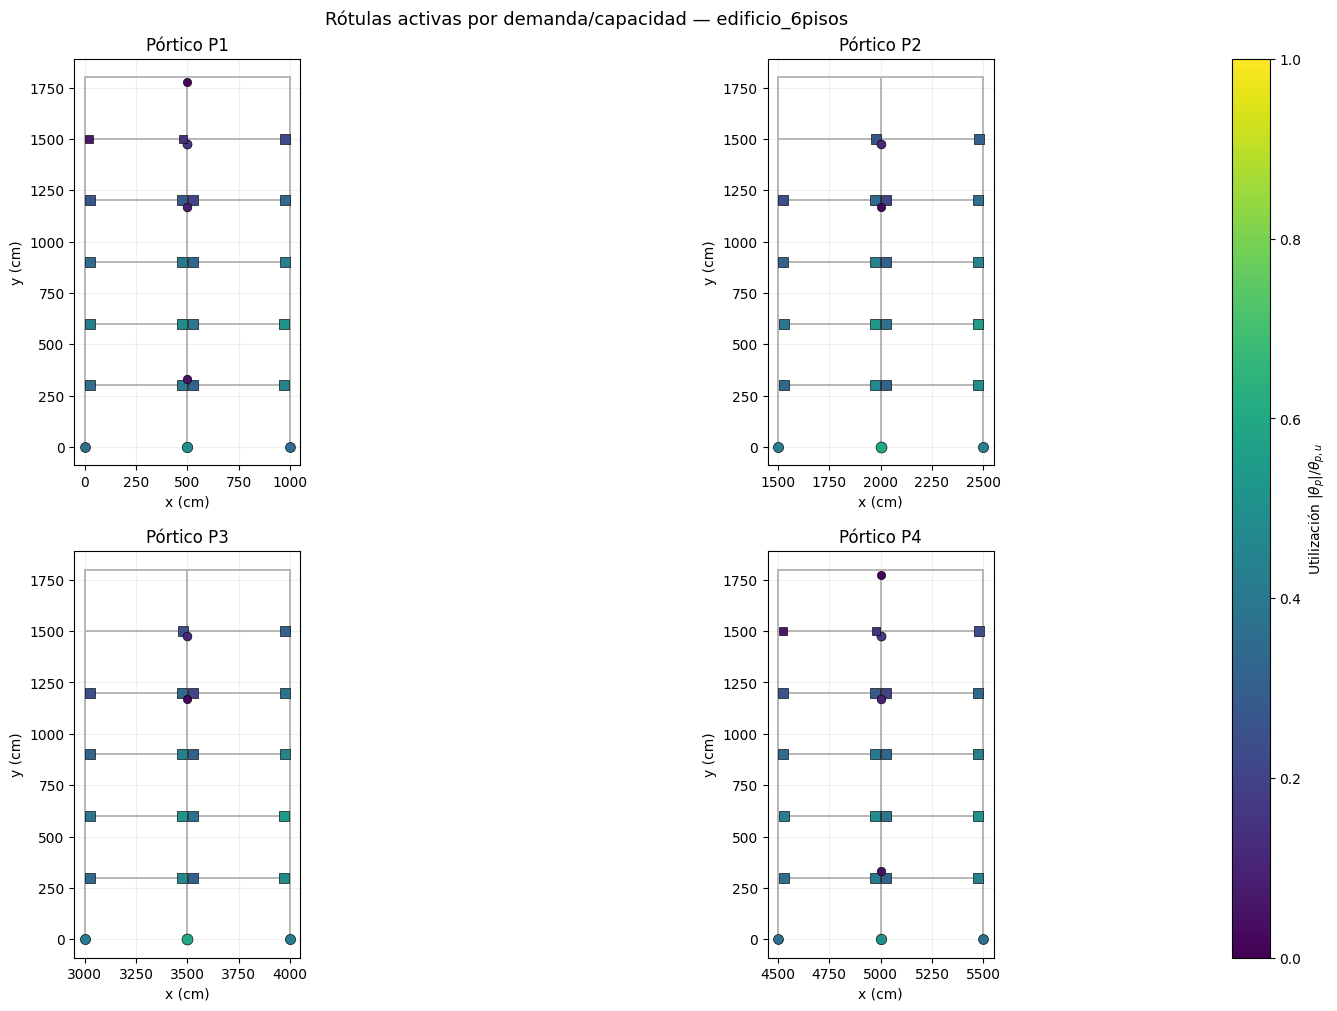

In [46]:
if POSPROCESO_DISPONIBLE and not tabla_rotulas.empty:
    porticos = sorted({str(e.get('id_portico')) for e in elementos.values()})
    ncols = min(2, len(porticos)); nrows = int(np.ceil(len(porticos)/ncols))
    fig = plt.figure(figsize=(7*ncols+0.9, 5*nrows), constrained_layout=True)
    rejilla = fig.add_gridspec(nrows, ncols+1, width_ratios=[1.0]*ncols+[0.055])
    axes_planos = [fig.add_subplot(rejilla[fila,col]) for fila in range(nrows) for col in range(ncols)]
    eje_barra = fig.add_subplot(rejilla[:, -1])
    util_max = max(1.0, float(np.nanmax(tabla_rotulas['utilizacion'])))
    norma_color = plt.Normalize(vmin=0.0, vmax=util_max)
    mapa_color = plt.cm.viridis

    for ax, pid in zip(axes_planos, porticos):
        elems_p = [e for e in elementos.values() if str(e.get('id_portico')) == pid]
        for e in elems_p:
            xi, yi = nodos[int(e['i'])]; xj, yj = nodos[int(e['j'])]
            ax.plot([xi,xj], [yi,yj], color='0.72', lw=1.4, zorder=1)
        activas_p = tabla_rotulas[tabla_rotulas['portico'].astype(str) == pid]
        for _, fila in activas_p.iterrows():
            rid = str(fila['rotula']); rot = rotulas[rid]; e = elementos[int(fila['elemento'])]
            ubicacion = rot.get('ubicacion', {})
            extremo = str(ubicacion.get('extremo', rid.rsplit('-',1)[-1]))
            punto_i = nodos[int(e['i'])]; punto_j = nodos[int(e['j'])]
            longitud_eje = float(np.linalg.norm(punto_j-punto_i))
            distancia_defecto = 0.0 if extremo == 'i' else longitud_eje
            distancia_i = float(ubicacion.get('x_desde_eje_i_cm', distancia_defecto))
            distancia_i = float(np.clip(distancia_i, 0.0, longitud_eje))
            punto_rotula = punto_i + (distancia_i/longitud_eje)*(punto_j-punto_i) if longitud_eje > 0 else punto_i
            x, y = punto_rotula; util = float(fila['utilizacion'])
            marcador = 'o' if fila['tipo'] == 'columna' else 's'
            ax.scatter(x, y, c=[mapa_color(norma_color(util))], s=35+45*min(util,1.5), marker=marcador, edgecolors='black', linewidths=0.45, zorder=3)
            if util >= 0.90:
                ax.annotate(f"{rid}\n{util:.2f}", (x,y), xytext=(5,5), textcoords='offset points', fontsize=7, color='darkred', zorder=4)
        ax.set_title(f'Pórtico {pid}')
        ax.set_xlabel('x (cm)'); ax.set_ylabel('y (cm)'); ax.set_aspect('equal'); ax.grid(True, alpha=0.18)
    for ax in axes_planos[len(porticos):]: ax.axis('off')
    escalar = plt.cm.ScalarMappable(norm=norma_color, cmap=mapa_color); escalar.set_array([])
    barra = fig.colorbar(escalar, cax=eje_barra)
    barra.set_label(r'Utilización $|\theta_p|/\theta_{p,u}$')
    fig.suptitle(f'Rótulas activas por demanda/capacidad — {CASO_ID}', fontsize=13)
    plt.show()
else:
    print('No existen rótulas activas para dibujar o todavía no se cargaron los resultados.')


### Pórticos asociados a cambios de sección críticos

Las columnas críticas se muestran en rojo y, cuando existe continuidad inferior, la columna inmediatamente inferior se muestra en naranja. La etiqueta indica `sección inferior → sección crítica`. Este esquema ayuda a reconocer concentraciones de demanda en transiciones de rigidez o resistencia.


In [47]:
if POSPROCESO_DISPONIBLE and filas_transicion:
    transiciones_unicas = {}
    for fila in filas_transicion:
        rid = str(fila['rotula']); eid = int(rotulas[rid]['elemento'])
        transiciones_unicas[eid] = fila
    porticos_transicion = sorted({str(f['portico']) for f in transiciones_unicas.values()})
    ncols = min(2, len(porticos_transicion)); nrows = int(np.ceil(len(porticos_transicion)/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows), squeeze=False)
    axes_planos = axes.ravel()
    for ax, pid in zip(axes_planos, porticos_transicion):
        elems_p = [e for e in elementos.values() if str(e.get('id_portico')) == pid]
        for e in elems_p:
            xi, yi = nodos[int(e['i'])]; xj, yj = nodos[int(e['j'])]
            ax.plot([xi,xj], [yi,yj], color='0.78', lw=1.2, zorder=1)
        for eid, fila in transiciones_unicas.items():
            e = elementos[eid]
            if str(e.get('id_portico')) != pid: continue
            inferior = next((x for x in elementos.values() if x.get('tipo')=='columna' and x.get('id_portico')==e.get('id_portico') and int(x['j'])==int(e['i'])), None)
            if inferior:
                xa, ya = nodos[int(inferior['i'])]; xb, yb = nodos[int(inferior['j'])]
                ax.plot([xa,xb], [ya,yb], color='darkorange', lw=4.0, zorder=2)
            xi, yi = nodos[int(e['i'])]; xj, yj = nodos[int(e['j'])]
            ax.plot([xi,xj], [yi,yj], color='crimson', lw=4.2, zorder=3)
            etiqueta = f"{fila.get('seccion_inferior') or 'base'} → {fila['seccion_actual']}"
            ax.annotate(etiqueta, ((xi+xj)/2,(yi+yj)/2), xytext=(6,0), textcoords='offset points', fontsize=8, color='darkred', weight='bold')
        ax.plot([],[],color='darkorange',lw=4,label='Columna inferior')
        ax.plot([],[],color='crimson',lw=4,label='Columna crítica')
        ax.set_title(f'Pórtico {pid}'); ax.set_xlabel('x (cm)'); ax.set_ylabel('y (cm)'); ax.set_aspect('equal'); ax.grid(True,alpha=0.18); ax.legend(fontsize=8)
    for ax in axes_planos[len(porticos_transicion):]: ax.axis('off')
    fig.suptitle(f'Transiciones de sección asociadas a rótulas críticas — {CASO_ID}', fontsize=13)
    fig.tight_layout(rect=[0,0,1,0.95]); plt.show()
else:
    print('No se identificaron transiciones de sección asociadas a rótulas con utilización ≥ 90 %.')


No se identificaron transiciones de sección asociadas a rótulas con utilización ≥ 90 %.


### Estado $M$–$\theta_p$ de una rótula para un desplazamiento lateral

Indica el identificador de la rótula y un desplazamiento de control. La celda selecciona el paso convergido más cercano y ubica el estado sobre la ley momento–rotación plástica. Los JSON nuevos de la sesión 06 guardan la rotación exacta por paso; para resultados antiguos se reconstruye a partir del momento de cara y la ley monotónica, y se informa expresamente en la tabla.


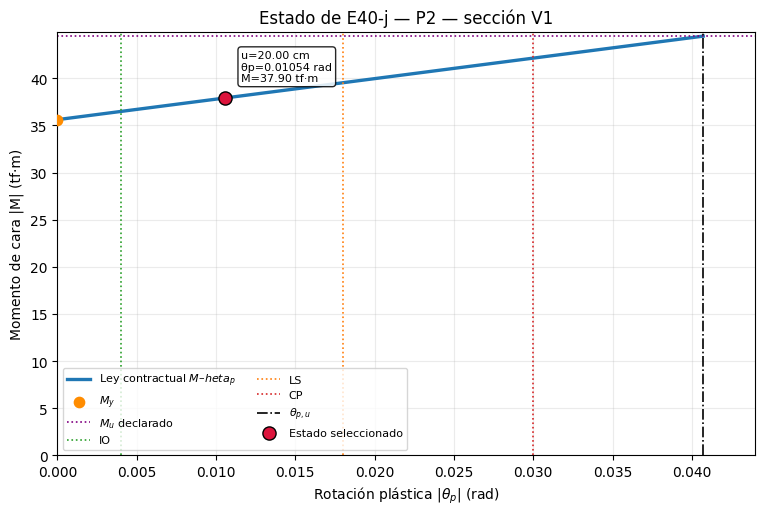

,rotula,elemento,extremo,portico,seccion,u_solicitado_cm,u_paso_usado_cm,paso,M_cara_tf_m,theta_p_rad,theta_p_u_rad,utilizacion,activo,desempeno,fuente_estado
0,E40-j,40,j,P2,V1,20.0,20.0,80,-37.90052,0.010542,0.040713,0.258931,True,LS,exacto: estado_rotulas guardado en el paso


In [49]:
ROTULA_SELECCIONADA = 'E40-j'
DESPLAZAMIENTO_LATERAL_CM = 20.0

if POSPROCESO_DISPONIBLE:
    rid = str(ROTULA_SELECCIONADA)
    if rid not in rotulas:
        raise KeyError(f'Rótula {rid!r} inexistente. Ejemplos: {list(rotulas)[:8]}')
    desplazamientos = np.asarray([p['desplazamiento_control_cm'] for p in historia], dtype=float)
    indice_paso = int(np.argmin(np.abs(desplazamientos-float(DESPLAZAMIENTO_LATERAL_CM))))
    paso_sel = historia[indice_paso]
    u_usado = float(paso_sel['desplazamiento_control_cm'])
    rot = rotulas[rid]; eid = int(rot['elemento']); e = elementos[eid]
    extremo = str(rot.get('ubicacion',{}).get('extremo', rid.rsplit('-',1)[-1]))
    fuerzas_paso = paso_sel.get('fuerzas_elementos', {})
    fuerzas_e = fuerzas_paso.get(str(eid), fuerzas_paso.get(eid))
    if fuerzas_e is None:
        raise KeyError(f'El paso {paso_sel["paso"]} no contiene fuerzas del elemento {eid}.')
    momento_cara = float(fuerzas_e['M_i_kgf_cm' if extremo=='i' else 'M_j_kgf_cm'])
    sentido = 'positivo' if momento_cara >= 0 else 'negativo'
    ley = rot.get('ley_por_sentido',{}).get(sentido, rot['ley'])
    criterios = rot.get('criterios_por_sentido',{}).get(sentido, rot.get('criterios_aceptacion',{}))
    My = float(ley['My_kgf_cm']); Mu = float(ley['Mu_kgf_cm']); Kp = float(ley['Kp_kgf_cm_rad']); theta_u = float(ley['theta_p_u_rad'])

    estado_paso = paso_sel.get('estado_rotulas',{}).get(rid)
    if estado_paso is not None:
        theta_demanda = abs(float(estado_paso.get('theta_p_rad',0.0)))
        momento_estado = abs(float(estado_paso.get('momento_kgf_cm',momento_cara)))
        activo = bool(estado_paso.get('activa',False)); desempeno = estado_paso.get('desempeno','elastica')
        fuente_estado = 'exacto: estado_rotulas guardado en el paso'
    else:
        activo = abs(momento_cara) > My
        theta_demanda = max((abs(momento_cara)-My)/Kp,0.0) if activo and Kp>0 else 0.0
        momento_estado = abs(momento_cara)
        limites = criterios.get('theta_p_rad',{})
        if not activo: desempeno = 'elastica'
        elif theta_demanda <= float(limites.get('IO',np.inf)): desempeno = 'IO'
        elif theta_demanda <= float(limites.get('LS',np.inf)): desempeno = 'LS'
        elif theta_demanda <= float(limites.get('CP',np.inf)): desempeno = 'CP'
        else: desempeno = 'excede_CP'
        fuente_estado = 'reconstruido desde momento de cara y ley monotónica'

    limites = criterios.get('theta_p_rad',{})
    theta_limites = [float(limites[k]) for k in ('IO','LS','CP') if k in limites]
    theta_graf_max = 1.08*max([theta_u,theta_demanda,1e-6]+theta_limites)
    theta = np.linspace(0.0,theta_u,250)
    momento_lineal = My + Kp*theta
    momento_contractual = np.minimum(momento_lineal,Mu)
    fig, ax = plt.subplots(figsize=(9,5.5))
    ax.plot(theta,momento_contractual/1e5,lw=2.4,label='Ley contractual $M$–$\theta_p$')
    if np.max(momento_lineal) > Mu*(1+1e-6):
        ax.plot(theta,momento_lineal/1e5,'--',lw=1.5,color='0.35',label='Continuación lineal del solucionador')
    ax.scatter(0,My/1e5,color='darkorange',s=55,zorder=4,label='$M_y$')
    ax.axhline(Mu/1e5,color='purple',ls=':',lw=1.2,label='$M_u$ declarado')
    colores_limite = {'IO':'#2ca02c','LS':'#ff7f0e','CP':'#d62728'}
    for nombre in ('IO','LS','CP'):
        if nombre in limites:
            ax.axvline(float(limites[nombre]),color=colores_limite[nombre],ls=':',lw=1.2,label=nombre)
    ax.axvline(theta_u,color='black',ls='-.',lw=1.2,label=r'$\theta_{p,u}$')
    ax.scatter(theta_demanda,momento_estado/1e5,color='crimson',edgecolor='black',s=90,zorder=6,label='Estado seleccionado')
    ax.annotate(f"u={u_usado:.2f} cm\nθp={theta_demanda:.5f} rad\nM={momento_estado/1e5:.2f} tf·m",(theta_demanda,momento_estado/1e5),xytext=(12,12),textcoords='offset points',fontsize=8,bbox=dict(boxstyle='round',fc='white',alpha=0.85))
    ax.set_xlim(left=0,right=theta_graf_max); ax.set_ylim(bottom=0)
    ax.set(xlabel=r'Rotación plástica $|\theta_p|$ (rad)',ylabel='Momento de cara |M| (tf·m)',title=f'Estado de {rid} — {e.get("id_portico")} — sección {e.get("seccion_id")}')
    ax.grid(True,alpha=0.25); ax.legend(fontsize=8,ncol=2); plt.show()

    resumen_rotula = pd.DataFrame([{'rotula':rid,'elemento':eid,'extremo':extremo,'portico':e.get('id_portico'),'seccion':e.get('seccion_id'),'u_solicitado_cm':float(DESPLAZAMIENTO_LATERAL_CM),'u_paso_usado_cm':u_usado,'paso':paso_sel['paso'],'M_cara_tf_m':momento_cara/1e5,'theta_p_rad':theta_demanda,'theta_p_u_rad':theta_u,'utilizacion':theta_demanda/theta_u if theta_u>0 else np.nan,'activo':activo,'desempeno':desempeno,'fuente_estado':fuente_estado}])
    display(resumen_rotula.round(6))
else:
    print('Ejecuta primero la sesión 06 y carga el bloque inicial del diagnóstico.')


### Criterios de interpretación

- `convergio=True` significa que los pasos aceptados satisfacen el equilibrio; la `razon_parada` determina por qué terminó la curva.
- Una parada por `limite_rotacion` indica que al menos una rótula superó su $\theta_{p,u}$ calculada. No debe prolongarse la curva sin definir y justificar una rama posúltima.
- La línea azul continua es la ley contractual limitada a $M_u$; la línea gris entrecortada es la continuación lineal $M=M_y+K_p|\theta_p|$ que emplea actualmente el solucionador. Si divergen, el JSON tiene $M_u$ declarado por separado y no una rama poscapping implementada.
- El índice de concentración de deriva es un indicador comparativo del modelo, no un límite normativo. Una concentración marcada requiere revisar cambios de rigidez/resistencia y un posible mecanismo de piso débil.
- Los límites IO–LS–CP provisionales no sustituyen la capacidad material ni una evaluación normativa verificada. Revisa también cortante, anclaje, empalmes, confinamiento y efectos P–Delta, que este modelo no comprueba automáticamente.
